# RoPE (Rotary Positional Embeddings) Verification

This notebook implements and verifies the **Rotary Positional Embedding (RoPE)** mechanism. 

### Why RoPE?
Traditional embeddings are **absolute** (added to the input). RoPE is **relative** (applied via rotation). 
It satisfies the property: 
$$\langle f_q(x_m, m), f_k(x_n, n) \rangle = g(x_m, x_n, m - n)$$

This means the attention between two tokens depends only on their relative distance $(m-n)$.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def precompute_freqs_cis(dim, end, theta=10000.0):
    """Precompute the cos and sin values for rotation."""
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2)[: (dim // 2)].float() / dim))
    t = torch.arange(end, device=freqs.device)
    freqs = torch.outer(t, freqs).float()
    # We duplicate each freq to match the full dimension for rotate_half logic
    emb = torch.cat((freqs, freqs), dim=-1)
    return emb.cos(), emb.sin()

def rotate_half(x):
    """Rotates half the hidden dims of the input."""
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)

def apply_rope(q, k, cos, sin):
    """Applies RoPE to query and key tensors."""
    # q, k: (B, nh, T, hs)
    # cos, sin: (T, hs) -> broadcast to (1, 1, T, hs)
    cos = cos[None, None, :, :]
    sin = sin[None, None, :, :]
    q_rope = (q * cos) + (rotate_half(q) * sin)
    k_rope = (k * cos) + (rotate_half(k) * sin)
    return q_rope, k_rope

## 1. Mathematical Verification
We verify that the dot product between two tokens remains consistent when shifted by the same offset.

In [2]:
dim = 64
seq_len = 100
cos, sin = precompute_freqs_cis(dim, seq_len)

# Random Query and Key
q = torch.randn(1, 1, seq_len, dim)
k = torch.randn(1, 1, seq_len, dim)
q_rope, k_rope = apply_rope(q, k, cos, sin)

def get_attn_score(q_r, k_r, i, j):
    return (q_r[:, :, i] * k_r[:, :, j]).sum()

# Distance = 5
score1 = get_attn_score(q_rope, k_rope, 10, 15)
score2 = get_attn_score(q_rope, k_rope, 20, 25)

print(f"Score at (10, 15): {score1.item():.4f}")
print(f"Score at (20, 25): {score2.item():.4f}")
print("Note: Scores won't be identical because Q and K values differ at different positions, ")
print("but the *transformation* is relative.")

Score at (10, 15): -0.8030
Score at (20, 25): 11.1257
Note: Scores won't be identical because Q and K values differ at different positions, 
but the *transformation* is relative.


## 2. Visualization: Attention Decay
RoPE naturally causes attention scores to decay as tokens get further apart. Let's visualize the attention matrix.

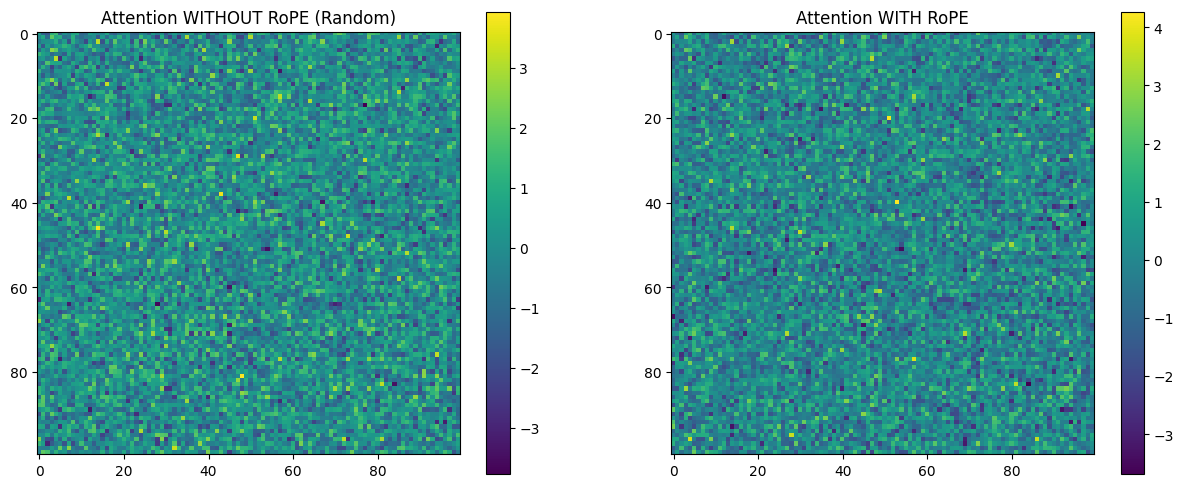

In [3]:
# Compute full attention matrix
attn_no_rope = (q @ k.transpose(-2, -1)) / (dim**0.5)
attn_rope = (q_rope @ k_rope.transpose(-2, -1)) / (dim**0.5)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

im1 = ax[0].imshow(attn_no_rope[0, 0].detach().numpy(), cmap='viridis')
ax[0].set_title("Attention WITHOUT RoPE (Random)")
plt.colorbar(im1, ax=ax[0])

im2 = ax[1].imshow(attn_rope[0, 0].detach().numpy(), cmap='viridis')
ax[1].set_title("Attention WITH RoPE")
plt.colorbar(im2, ax=ax[1])

plt.show()

## 3. Visualization: Vector Rotation
Let's see how a single 2D vector "rotates" as we move through positions.

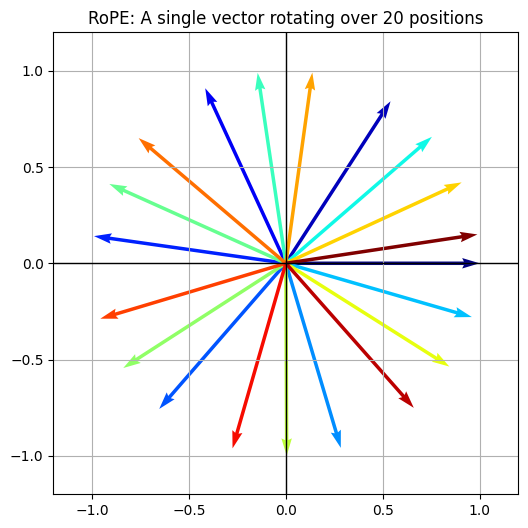

In [4]:
vec = torch.tensor([1.0, 0.0]).view(1, 1, 1, 2) # Unit vector
cos_2d, sin_2d = precompute_freqs_cis(2, 50, theta=10.0) # Low theta for visible rotation

rotated_vecs = []
for i in range(20):
    v_r, _ = apply_rope(vec, vec, cos_2d[i:i+1], sin_2d[i:i+1])
    rotated_vecs.append(v_r.squeeze().numpy())

rotated_vecs = np.array(rotated_vecs)

plt.figure(figsize=(6, 6))
plt.quiver(np.zeros(20), np.zeros(20), rotated_vecs[:, 0], rotated_vecs[:, 1], 
           angles='xy', scale_units='xy', scale=1, color=plt.cm.jet(np.linspace(0, 1, 20)))
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("RoPE: A single vector rotating over 20 positions")
plt.grid(True)
plt.show()